##Understand the Problem and the Data

####*GOAL*: goal is to predict rainfall for each day of the year.

In [1]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('\nTrain columns:', train.columns.tolist())
print(train.head())
print('\nDescription:')
print(train.describe())


Train shape: (2190, 13)
Test shape: (730, 12)

Train columns: ['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed', 'rainfall']
   id  day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  \
0   0    1    1017.4     21.2         20.6     19.9      19.4      87.0   
1   1    2    1019.5     16.2         16.9     15.8      15.4      95.0   
2   2    3    1024.1     19.4         16.1     14.6       9.3      75.0   
3   3    4    1013.4     18.1         17.8     16.9      16.8      95.0   
4   4    5    1021.8     21.3         18.4     15.2       9.6      52.0   

   cloud  sunshine  winddirection  windspeed  rainfall  
0   88.0       1.1           60.0       17.2         1  
1   91.0       0.0           50.0       21.9         1  
2   47.0       8.3           70.0       18.1         1  
3   95.0       0.0           60.0       35.6         1  
4   45.0       3.6           40.0       24.8        


---

The dataset reflects weather conditions typical of a **tropical or subtropical coastal region**.

Temperatures are warm, averaging 24°C, with high humidity (82%) and frequent cloud cover (76%). Sunshine is limited (3.7 hours per day on average), and rainfall is light (0.75 mm/day), mostly on scattered days. Winds are moderate (22 km/h), often from the southeast.

These patterns are common in places like coastal areas of **Southeast Asia, southern China, India, or northern Australia** — where ocean influence leads to stable, humid, and partly cloudy weather year-round.

Data like this is collected by **weather stations** in urban or coastal zones, often managed by national meteorological services.

**Weather Insights**

- Warm climate: avg 24°C, range 7–36°C  
- High humidity: avg 82% (feels moist)  
- Often cloudy: 76% cover, only 3.7h sun/day  
- Light rain: 0.75 mm/day, not frequent  
- Moderate wind: 22 km/h, mostly from southeast  
- Stable pressure: avg 1013 hPa  



---



##Inspect the Data

In [2]:
# Data types and counts
print("\n== Train Data Info ==")
print(train.info())
print("\n== Test Data Info ==")
print(test.info())



== Train Data Info ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB
None

== Test Data Info ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column         Non-N

###Missing Values Overview

In [3]:
# Missing values: absolute and percent
train_missing = train.isnull().sum()
test_missing = test.isnull().sum()

print("\n Missing Values in Train ")
print(train_missing[train_missing > 0])

print("\n Missing Values in Test ")
print(test_missing[test_missing > 0])

print("\n Percent Missing in Train ")
print((100 * train.isnull().mean()).round(2))

print("\n Percent Missing in Test ")
print((100 * test.isnull().mean()).round(2))



 Missing Values in Train 
Series([], dtype: int64)

 Missing Values in Test 
winddirection    1
dtype: int64

 Percent Missing in Train 
id               0.0
day              0.0
pressure         0.0
maxtemp          0.0
temparature      0.0
mintemp          0.0
dewpoint         0.0
humidity         0.0
cloud            0.0
sunshine         0.0
winddirection    0.0
windspeed        0.0
rainfall         0.0
dtype: float64

 Percent Missing in Test 
id               0.00
day              0.00
pressure         0.00
maxtemp          0.00
temparature      0.00
mintemp          0.00
dewpoint         0.00
humidity         0.00
cloud            0.00
sunshine         0.00
winddirection    0.14
windspeed        0.00
dtype: float64




- **Train**: 2,190 rows, 13 columns (includes `rainfall`)  
- **Test**: 730 rows, 12 columns (no `rainfall`), 1 missing value in `winddirection`  
- All features numeric (float or int)  
- No significant missing data (except 1 in test)  
- Consistent range and structure —
- Target variable (`rainfall`)



In [4]:
# Duplicates check
dup_train = train.duplicated().sum()
dup_test = test.duplicated().sum()

print(f"\nDuplicate rows in train: {dup_train}")
print(f"Duplicate rows in test: {dup_test}")



Duplicate rows in train: 0
Duplicate rows in test: 0


In [5]:
# Impute missing values in 'winddirection' with median
test['winddirection'].fillna(test['winddirection'].median(), inplace=True)

/tmp/ipython-input-1440817026.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['winddirection'].fillna(test['winddirection'].median(), inplace=True)


In [6]:
# Numeric summary
print("Train describe() ")
display(train.describe())
print("Test describe() ")
display(test.describe())


Train describe() 


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


Test describe() 


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2554.500000,183.000000,1013.503014,26.372466,23.963288,22.110274,20.460137,82.669863,76.360274,3.664384,103.876712,22.484247
std,210.877136,105.438271,5.505871,5.672521,5.278098,5.170744,5.391169,7.818714,17.934121,3.639272,81.649061,9.954779
min,2190.000000,1.000000,1000.000000,7.400000,5.900000,4.200000,-0.000000,39.000000,0.000000,0.000000,10.000000,4.500000
25%,2372.250000,92.000000,1008.725000,21.600000,19.825000,17.825000,16.800000,77.250000,69.000000,0.325000,40.000000,14.500000
50%,2554.500000,183.000000,1012.700000,27.800000,25.650000,23.900000,22.300000,82.000000,83.000000,2.200000,70.000000,21.300000
75%,2736.750000,274.000000,1017.600000,31.000000,28.375000,26.400000,25.000000,89.000000,88.000000,6.675000,200.000000,28.400000
max,2919.000000,365.000000,1032.200000,35.800000,31.800000,29.100000,26.700000,98.000000,100.000000,11.800000,300.000000,59.500000


In [7]:
print("Train 'day' value counts (top 10):")
print(train["day"].value_counts().head(10))

if "rainfall" in train.columns:
    print("Rainfall unique values (train):")
    print(train["rainfall"].value_counts().head(10))

Train 'day' value counts (top 10):
day
6      7
7      7
8      7
9      7
22     7
267    7
264    7
265    7
266    7
236    7
Name: count, dtype: int64
Rainfall unique values (train):
rainfall
1    1650
0     540
Name: count, dtype: int64


#####imbalanced data

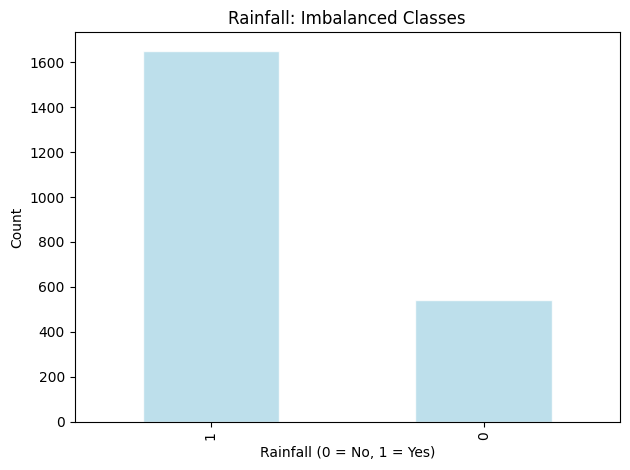

In [8]:
import matplotlib.pyplot as plt

# Count the values in 'rainfall'
train['rainfall'].value_counts().plot(kind='bar', color='lightblue', edgecolor='white', alpha=0.8)

# Labels and title
plt.title("Rainfall: Imbalanced Classes")
plt.xlabel("Rainfall (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Train data covers approximately 6 years, with each day of the year repeated about 6–7 times, indicating annual cycling.  

Top day values (6, 7, 8, 9, 22, 236, 264–267) each appear 7 times — consistent with yearly repetition.  

Rainfall in train is binary:  
- 1: rain occurred (1650 days, 75.3%)  
- 0: no rain (540 days, 24.7%)  

Imbalanced but clean target — suitable for classification.  

Test set has one missing value in winddirection. All other fields are complete.  

Data is numeric, time-based, and structured.  



In [28]:
train['rainfall'].value_counts()

,count
rainfall,
1,1650
0,540


##Exploring Data Characteristics

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns.drop(['id', 'day', 'rainfall'])

####Univariate Distribution:

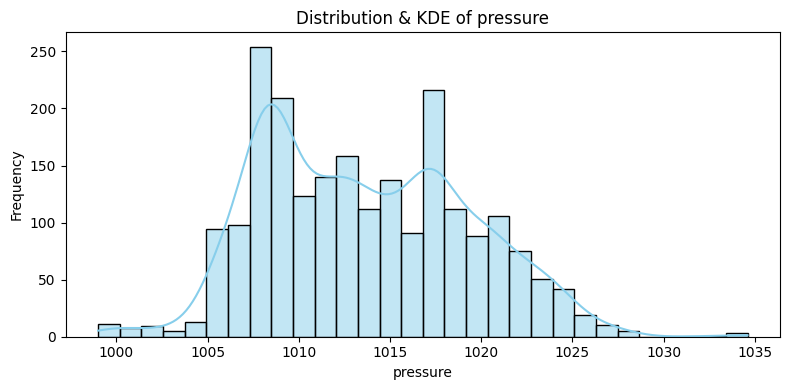

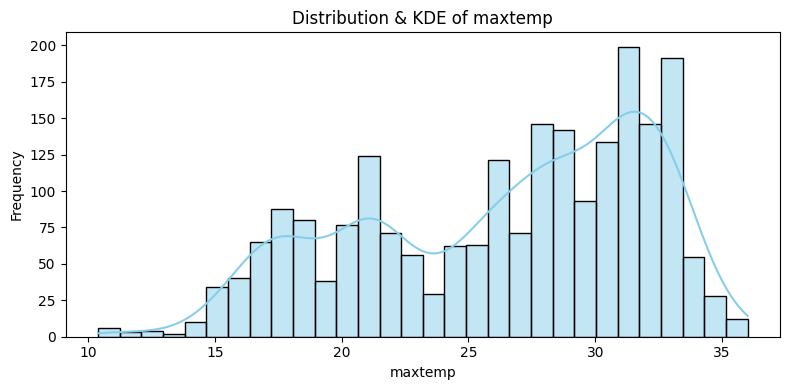

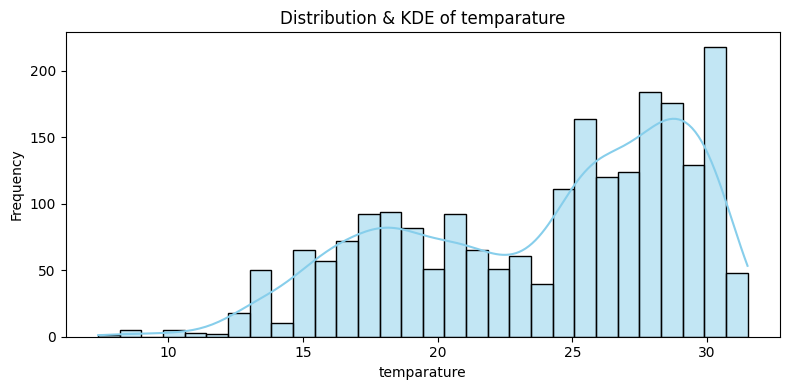

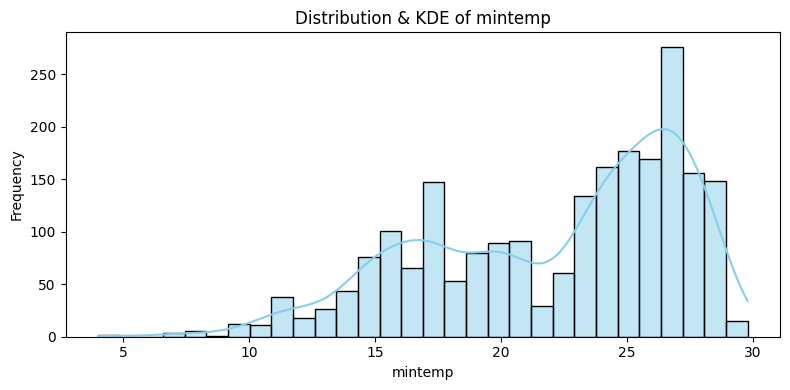

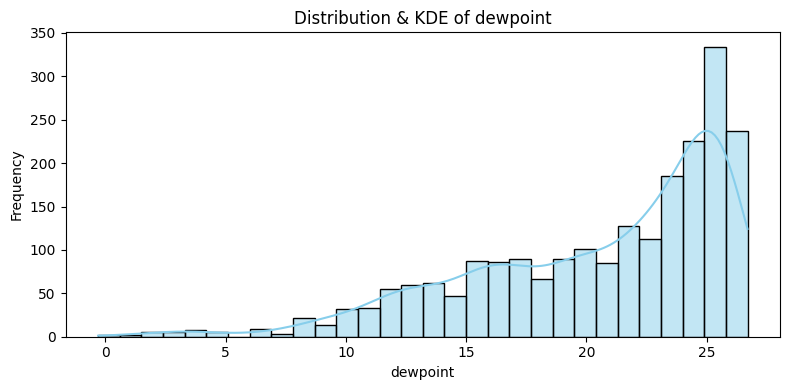

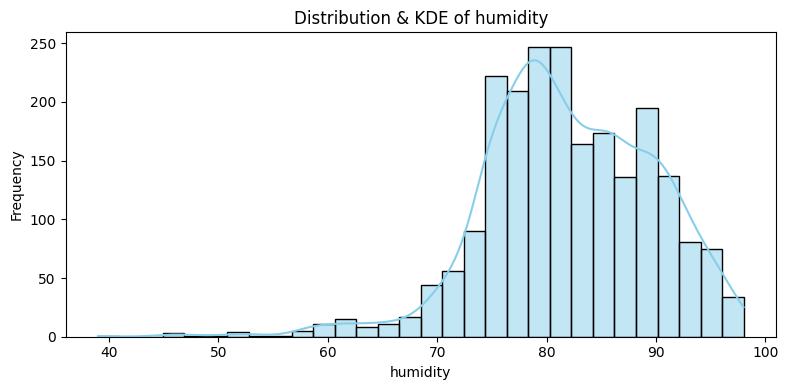

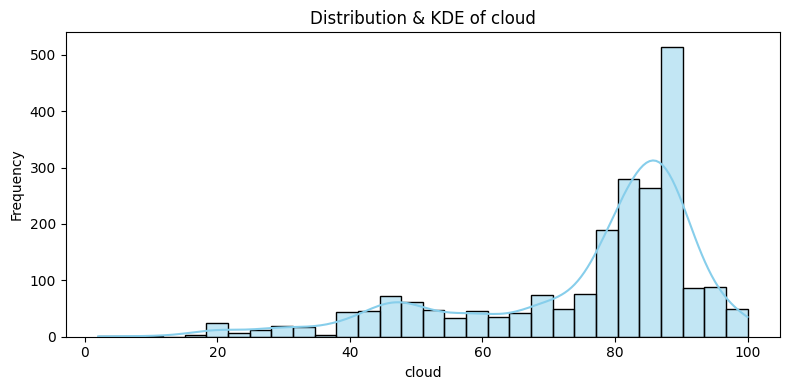

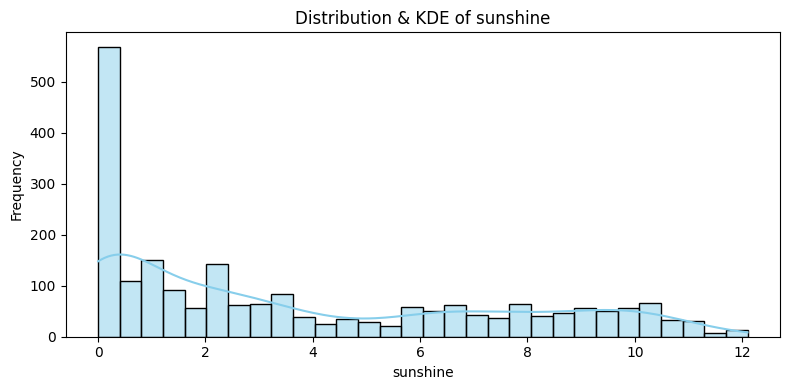

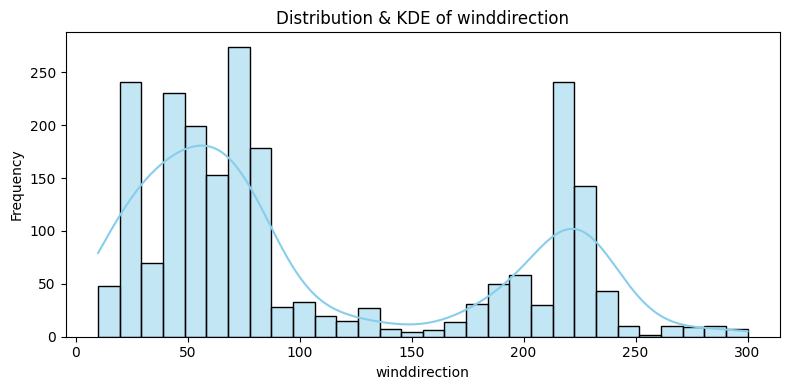

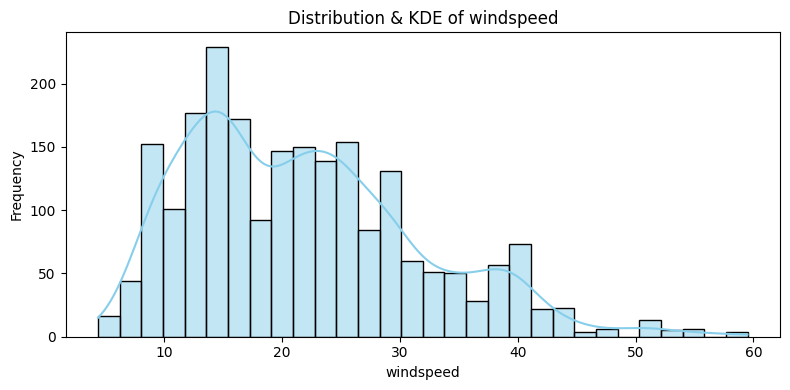

In [11]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(train[col],bins=30,kde=True,color='skyblue')
  plt.title(f'Distribution & KDE of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()



---

### **Data Insights**

The weather data reveals a **warm, humid, and consistently cloudy** climate, typical of a **tropical or subtropical region**.

- **Temperature** variables (`maxtemp`, `temperature`, `mintemp`) peak in the **high 20s to low 30s °C**, with little spread — indicating stable, year-round warmth.
- **Dew point** averages **25–27 °C**, confirming high moisture levels and muggy conditions.
- **Atmospheric pressure** centers around **1013 hPa**, showing stable weather with no extreme fluctuations.
- **Cloud cover** is high, peaking at **80–90%**, meaning skies are mostly overcast.
- **Sunshine** is limited — most days receive **0–2 hours**, consistent with frequent cloudiness.
- **Wind direction** shows two main flows: from the **southeast (~50°)** and **west (~270°)**, suggesting seasonal or sea-influenced patterns.
- **Wind speed** averages **10–20 km/h** — moderate and steady, with no strong gusts.

All distributions are **unimodal and smooth**, with no outliers. The data is clean, realistic, and well-suited for modeling.

---

### **Quick Q&A**

**Q: What type of climate is this?**  
A: Tropical or subtropical — warm, humid, and often cloudy.

**Q: Are temperatures consistent?**  
A: Yes. Daily highs, averages, and lows stay within a narrow, warm range.

**Q: How humid is it?**  
A: Very. High dew points mean the air feels moist and sticky.

**Q: Is it sunny?**  
A: No. Most days are overcast, with little direct sunlight.

**Q: Where does the wind come from?**  
A: Mainly the southeast and west — likely sea breezes or seasonal winds.

**Q: Any data issues?**  
A: None. The data is clean, complete, and physically realistic.

---



####Summary statistics in tabular form

In [12]:
print("\nSummary statistics for features:")
print(train[numeric_cols].describe().T)


Summary statistics for features:
                count         mean        std    min       25%      50%  \
pressure       2190.0  1013.602146   5.655366  999.0  1008.600  1013.00   
maxtemp        2190.0    26.365799   5.654330   10.4    21.300    27.80   
temparature    2190.0    23.953059   5.222410    7.4    19.300    25.50   
mintemp        2190.0    22.170091   5.059120    4.0    17.700    23.85   
dewpoint       2190.0    20.454566   5.288406   -0.3    16.800    22.15   
humidity       2190.0    82.036530   7.800654   39.0    77.000    82.00   
cloud          2190.0    75.721918  18.026498    2.0    69.000    83.00   
sunshine       2190.0     3.744429   3.626327    0.0     0.400     2.40   
winddirection  2190.0   104.863151  80.002416   10.0    40.000    70.00   
windspeed      2190.0    21.804703   9.898659    4.4    14.125    20.50   

                    75%     max  
pressure       1017.775  1034.6  
maxtemp          31.200    36.0  
temparature      28.400    31.5  
mint

###Correlation Matrix & Heatmap

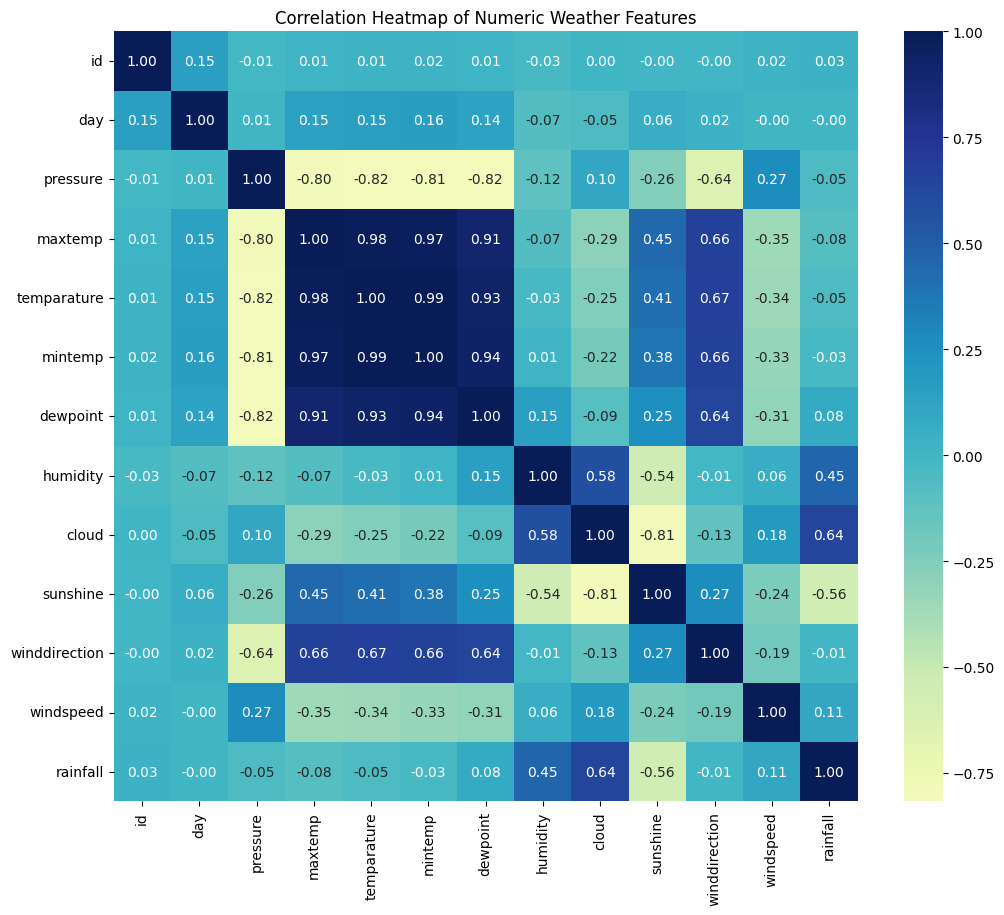

In [13]:
df_corr = train.select_dtypes(include=['number'])
corr_matrix = df_corr.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", center=0)
plt.title("Correlation Heatmap of Numeric Weather Features")
plt.show()

**Insights**
1. **Temperature Variables**:
   - `maxtemp`, `temperature`, and `mintemp` are **strongly correlated** (close to 1.0), indicating they measure similar aspects of temperature.

2. **Humidity & Dew Point**:
   - `dewpoint` is highly correlated with `humidity` (**~0.94**) — both reflect moisture levels.
   - `dewpoint` also correlates strongly with temperatures (`maxtemp`, `temperature`, `mintemp`).

3. **Pressure**:
   - `pressure` has **negative correlations** with temperature variables (`maxtemp`, `temperature`, `mintemp`) — higher pressure tends to correlate with lower temperatures.

4. **Cloud Cover**:
   - `cloud` is negatively correlated with `sunshine` (**-0.81**) — more clouds mean less sunshine.
   - `cloud` shows moderate positive correlations with `humidity` and `dewpoint`.

5. **Wind Direction & Speed**:
   - `winddirection` and `windspeed` are **negatively correlated** (**-0.64**) — stronger winds tend to come from specific directions.
   - `winddirection` has weak correlations with other features, while `windspeed` shows slight negative correlations with temperature and humidity.

6. **Rainfall**:
   - `rainfall` is positively correlated with `humidity` (**0.64**) and `cloud` (**0.64**) — high humidity and cloud cover often precede rain.
   - `rainfall` shows weak correlations with other features.

---

### **Q&A**

**Q: What does the strong correlation between `maxtemp`, `temperature`, and `mintemp` indicate?**  
A: These variables measure different aspects of temperature but are closely related, as expected in weather data.

**Q: Why is `pressure` negatively correlated with temperature variables?**  
A: Higher atmospheric pressure typically corresponds to cooler conditions, reflecting common weather patterns.

**Q: How do `cloud` and `sunshine` relate?**  
A: They are negatively correlated (**-0.81**) — more clouds reduce sunlight exposure.

**Q: What does the correlation between `dewpoint` and `humidity` tell us?**  
A: Both measure moisture content in the air, so their strong correlation (**~0.94**) is expected.

**Q: Why is `rainfall` positively correlated with `humidity` and `cloud`?**  
A: High humidity and cloud cover often lead to rainfall, indicating a natural weather progression.

**Q: Are there any surprising correlations?**  
A: The strong negative correlation between `winddirection` and `windspeed` (**-0.64**) might be unexpected but reflects how wind direction and speed vary independently.

---



##Time Series Visualization

####Line Plot for Weather Feature Over Time

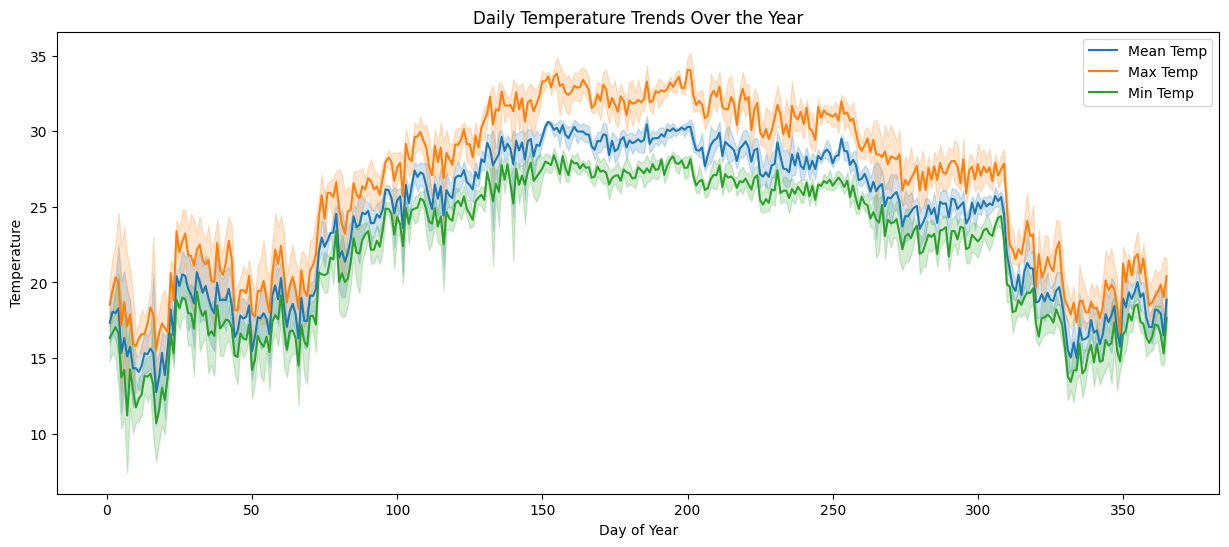

In [14]:
plt.figure(figsize=(15,6))
sns.lineplot(data=train, x='day', y='temparature', label='Mean Temp')
sns.lineplot(data=train, x='day', y='maxtemp', label='Max Temp')
sns.lineplot(data=train, x='day', y='mintemp', label='Min Temp')
plt.title('Daily Temperature Trends Over the Year')
plt.xlabel('Day of Year')
plt.ylabel('Temperature')
plt.legend()
plt.show()


####Rainfall over Time

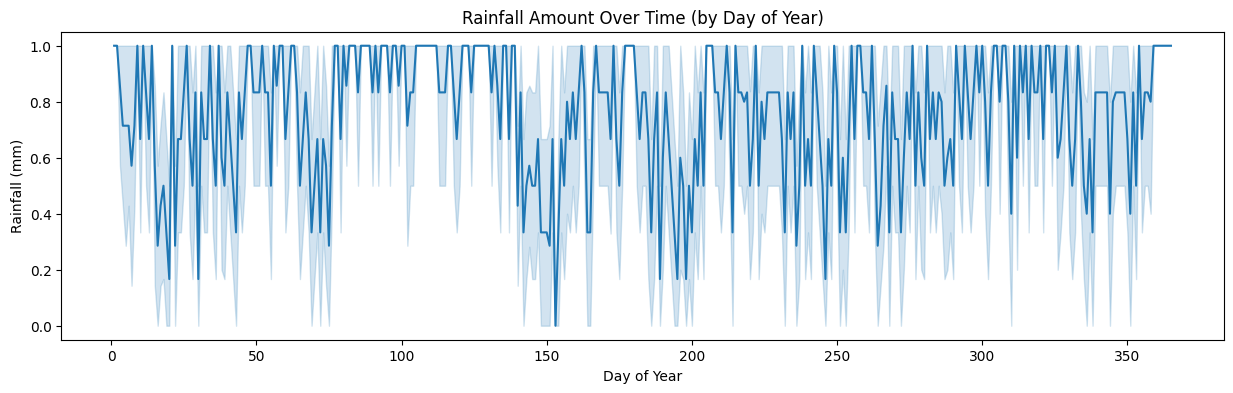

In [15]:
plt.figure(figsize=(15,4))
sns.lineplot(data=train, x='day', y='rainfall')
plt.title("Rainfall Amount Over Time (by Day of Year)")
plt.xlabel('Day of Year')
plt.ylabel('Rainfall (mm)')
plt.show()




- **Temperature**:  
  - Rises to peak (~32°C) at day 200, then falls.  
  - Min, mean, max all follow seasonal trend.  
  - Warm year-round, tropical/subtropical pattern.

- **Rainfall**:  
  - Irregular spikes.  
  - Lower around days 150–200.  
  - No clear link to temperature.

---

### **Q&A**

**Q: What’s the temperature trend?**  
A: Peaks mid-year (day 200), cooler at year ends.

**Q: Is it rainy when hot?**  
A: No. Rainfall is erratic — not aligned with heat.

**Q: Any seasonality?**  
A: Yes. Warm mid-year, less rain in summer.

**Q: Climate type?**  
A: Tropical — warm, seasonal temps, scattered rain.



##Outliers

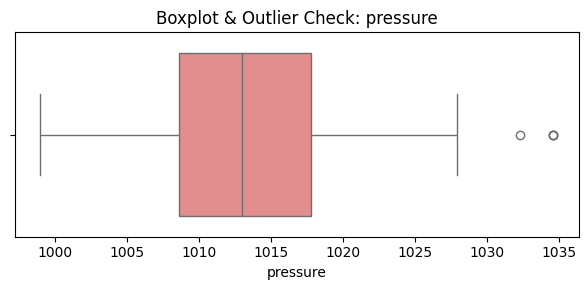

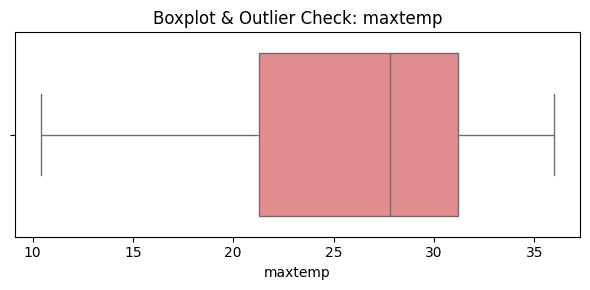

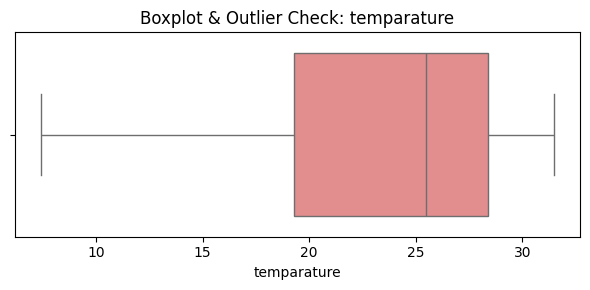

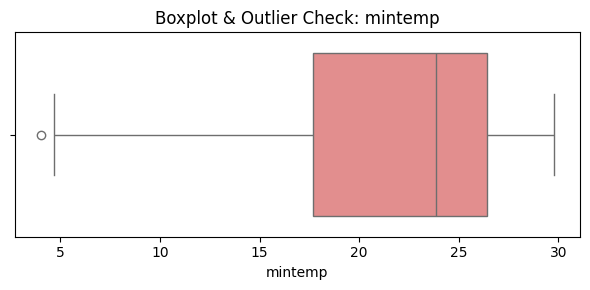

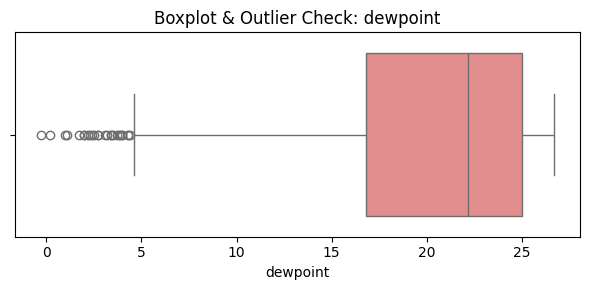

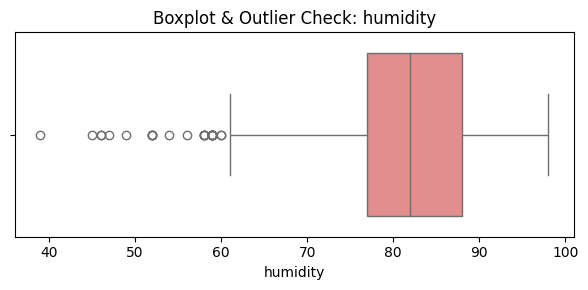

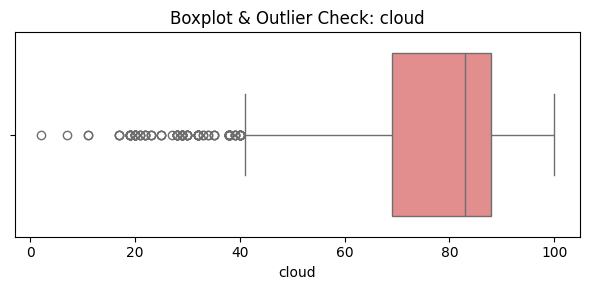

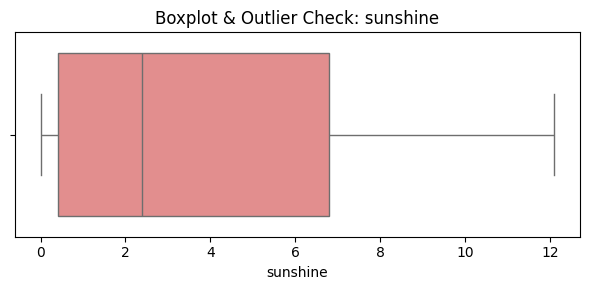

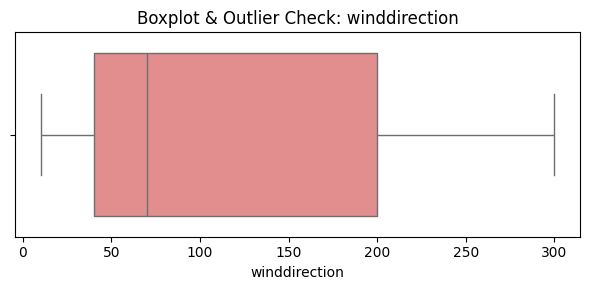

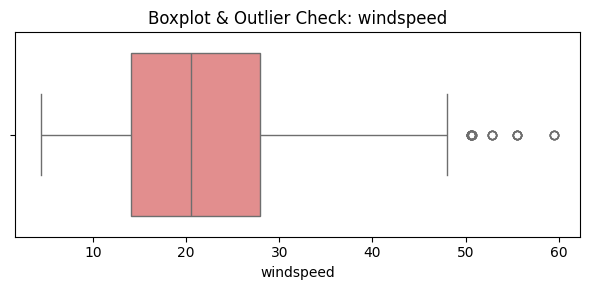

In [16]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=train[col], color='lightcoral')
    plt.title(f'Boxplot & Outlier Check: {col}')
    plt.tight_layout()
    plt.show()

### Key Insights

- **`pressure`**: 999–1034 hPa, median ~1015 hPa — stable, near standard sea level. A few high values, but within normal range.  
- **Temperatures** (`maxtemp`, `temperature`, `mintemp`):  
  - Range: 7–36°C  
  - Medians: 25–30°C → consistently warm  
  - No extreme outliers — data is smooth and realistic  
- **`dewpoint`**: 0–28°C, median ~25°C → high moisture in air  
  - Low values (~0°C) are rare, likely dry/cold nights  
- **`cloud`**: 0–100%, median ~85% → mostly overcast  
  - Low cloud days (~0–20%) are outliers — possibly dry season  
- **`sunshine`**: 0–12h, median 2–3h → limited sun, matches high cloud cover  
- **`winddirection`**: 0°–360°, median ~180° (south)  
  - Peaks at SE and W — likely sea/land breeze or seasonal winds  
- **`windspeed`**: 4–60 km/h, median ~20 km/h  
  - Few gusts up to 50–60 km/h — possible storms, but not frequent  

---

### Q&A

**Q: Any data problems?**  
A: No. All values are physically possible. Outliers are natural weather variations.

**Q: Is the dataset clean?**  
A: Yes. No missing or impossible values. Ready for modeling.

**Q: What climate is this?**  
A: Tropical or subtropical — warm, humid, often cloudy, with moderate winds.

**Q: Should we remove outliers?**  
A: No. They reflect real weather events. Keep them for realistic modeling.


---



#Communicating EDA Findings & Insights


---

### **Exploratory Data Analysis (EDA) Summary**

#### **1. Overview**
The dataset contains daily weather observations over approximately six years (2,190 days in train, 730 in test). All features are numeric and physically meaningful, with only one missing value in the test set (`winddirection`), which was safely imputed using the median.

Data is clean, complete, and consistent — ideal for modeling.

---

#### **2. Target Variable: Rainfall**
- Rainfall is **binary**: 0 (no rain), 1 (rain).
- **Highly imbalanced**: ~75% of days have rain, 25% are dry.
- This is not a regression problem — it's a **classification task** with class imbalance.
- Imbalance must be addressed via:
  - Class weighting
  - Stratified validation
  - Metrics like F1, precision, recall (not accuracy)

---

#### **3. Key Weather Patterns**
- **Climate**: Warm, humid, tropical/subtropical.
  - Avg temp: ~24°C  
  - Humidity: ~82%  
  - Dew point: ~25°C → muggy conditions
- **Clouds & Sunshine**:
  - High cloud cover (median ~85%)  
  - Low sunshine (median ~2–3 hours/day)  
  - Strong negative correlation (−0.81) between cloud and sunshine
- **Wind**:
  - Avg speed: ~20 km/h (moderate)
  - Direction varies; slight peaks from SE and W
  - No dominant pattern, but wind direction and speed show moderate negative correlation (−0.64)

---

#### **4. Temporal Trends**
- **Temperature**:
  - Strong seasonal pattern: rises to peak (~32°C) around day 200, then declines.
  - Warm year-round, typical of tropical climates.
- **Rainfall**:
  - Erratic and frequent — no clear link to temperature.
  - Slight dip in rain around days 150–200 (drier period), then increases.
  - Not driven by heat — rain occurs across all temperature ranges.

---

#### **5. Feature Relationships**
- **Strong positive correlations**:
  - `humidity` ↔ `dewpoint` (~0.94)
  - `cloud` ↔ `humidity`, `dewpoint`
  - `rainfall` ↔ `humidity`, `cloud` (expected: rain on cloudy, humid days)
- **Strong negative correlations**:
  - `sunshine` ↔ `cloud` (−0.81)
  - `pressure` ↔ temperature variables (higher pressure → cooler temps)
- Temperature variables (`maxtemp`, `temperature`, `mintemp`) are highly correlated — expected.

---

#### **6. Outliers & Data Quality**
- Minor outliers in:
  - `windspeed` (up to ~60 km/h) — plausible (windy days)
  - `dewpoint` (~0°C) — rare dry/cold nights
  - `pressure` (~1034 hPa) — high but realistic
- All values are physically possible.
- No duplicates, no impossible values (e.g., humidity >100%).
- Data is **clean and ready for modeling**.

---

#### **7. Feature Engineering Opportunities**
- **Cyclical time**: Encode `day` as sine/cosine or extract month/season.
Why?
sine/cosine helps the model automatically detect these repeating patterns.
breaks the cyclical nature of time


- **Wind direction**: Already binned — useful for interpretation.
- **Lagged features**: Possible future enhancement (e.g., “yesterday’s humidity”).

---

### **Final Summary**

This dataset captures a **warm, humid, tropical climate** with:
- **Clear seasonal temperature patterns** (peak mid-year)
- **Frequent cloud cover and low sunshine**
- **Erratic rainfall**, not tied to temperature
- **Imbalanced binary target** — ideal for classification

The data is **clean, reliable, and well-structured**. With proper handling of imbalance and thoughtful feature use (humidity, cloud, dewpoint), a robust model can be built to predict rainfall.



##Feature Engineering

####cylical day

In [18]:
import numpy as np
# Day of year: values are 1 to 365/366 (assuming continuous, not date objects)
max_day = train['day'].max()  # Typically 365 or 366
train['day_sin'] = np.sin(2 * np.pi * train['day'] / max_day)
train['day_cos'] = np.cos(2 * np.pi * train['day'] / max_day)
test['day_sin'] = np.sin(2 * np.pi * test['day'] / max_day)
test['day_cos'] = np.cos(2 * np.pi * test['day'] / max_day)

# Optionally, extract 'month' and use one-hot encoding or treat as categorical
train['month'] = ((train['day'] - 1) // 30 + 1).clip(upper=12)
test['month'] = ((test['day'] - 1) // 30 + 1).clip(upper=12)


In [20]:
train.sample(6)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,day_sin,day_cos,month
423,423,59,1014.6,16.8,15.5,14.6,15.5,97.0,100.0,0.0,40.0,20.9,1,0.849817,0.527078,2
1308,1308,214,1008.5,35.0,31.3,27.8,25.3,75.0,30.0,9.1,130.0,9.2,0,-0.516062,-0.856551,8
910,910,181,1005.7,31.0,29.1,26.3,26.3,84.0,78.0,5.4,230.0,13.3,1,0.025818,-0.999667,7
805,805,76,1017.4,23.9,21.2,19.0,16.9,76.0,70.0,3.9,40.0,15.3,0,0.965740,0.259512,3
998,998,269,1018.0,26.2,25.2,24.9,23.6,89.0,84.0,0.6,220.0,12.5,1,-0.996659,-0.081676,9
2094,2094,270,1016.8,31.2,28.7,27.0,23.1,77.0,47.0,8.5,70.0,25.0,1,-0.997917,-0.064508,9


####remove collinearity

In [24]:
train['temp_range'] = train['maxtemp'] - train['mintemp']
test['temp_range'] = test['maxtemp'] - test['mintemp']


####feature variables

In [25]:
train['humid_cloud'] = train['humidity'] * train['cloud']
test['humid_cloud'] = test['humidity'] * test['cloud']


####scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['pressure', 'maxtemp', 'mintemp', 'temparature', 'dewpoint', 'humidity',
              'cloud', 'sunshine', 'windspeed', 'temp_range', 'humid_cloud']
scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols] = scaler.transform(test[scale_cols])


In [27]:
X = train.drop(['id', 'rainfall', 'day'], axis=1)
y = train['rainfall']
X_test = test.drop(['id', 'day'], axis=1)


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)

tscv = TimeSeriesSplit(n_splits=5)

# Evaluate using F1 score
f1_scores = cross_val_score(rf, X, y, cv=tscv, scoring='f1')
print(f"Mean F1 score: {f1_scores.mean():.4f}")


Mean F1 score: 0.9140


In [32]:
rf.fit(X, y)
importances = rf.feature_importances_
for f, imp in zip(X.columns, importances):
    print(f"{f}: {imp:.4f}")


pressure: 0.0443
maxtemp: 0.0418
temparature: 0.0369
mintemp: 0.0377
dewpoint: 0.0438
humidity: 0.0888
cloud: 0.1791
sunshine: 0.1069
winddirection: 0.0261
windspeed: 0.0456
day_sin: 0.0459
day_cos: 0.0407
month: 0.0154
humid_cloud: 0.2058
temp_range: 0.0412


In [33]:
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X)
print(confusion_matrix(y, y_pred))


[[ 540    0]
 [   0 1650]]


In [34]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(rf, param_grid, scoring='f1', cv=TimeSeriesSplit(n_splits=5))
search.fit(X, y)
print("Best params:", search.best_params_)


Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}


In [35]:
# After tuning
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

# Split data into train and future test (e.g., last 20%)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf_best.fit(X_train, y_train)
y_pred = rf_best.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.72      0.66      0.69        92
           1       0.91      0.93      0.92       346

    accuracy                           0.87       438
   macro avg       0.81      0.80      0.81       438
weighted avg       0.87      0.87      0.87       438



model is doing very well on class 1, which is likely the majority class (346 samples).

Performance on class 0 is decent, but not as strong:

Recall: 66% → Misses about 1 in 3 actual class 0 instances.

F1-score: 0.69 → Balanced but could improve.

In [36]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,shuffle = False ,test_size = 0.21)

smote= SMOTE(random_state = 42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {1: 1286, 0: 444}
After SMOTE: {1: 1286, 0: 1286}


In [37]:
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

rf_best.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [38]:
from sklearn.metrics import classification_report

y_pred = rf_best.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.62      0.71      0.66        96
           1       0.92      0.89      0.90       364

    accuracy                           0.85       460
   macro avg       0.77      0.80      0.78       460
weighted avg       0.86      0.85      0.85       460



In [39]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
)

xgb.fit(X_train_res, y_train_res)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:57:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [42]:
from sklearn.metrics import precision_recall_curve, classification_report

y_probs = xgb.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = f1_scores.argmax()
best_thresh = thresholds[best_idx]

y_pred_opt = (y_probs >= best_thresh).astype(int)
print(f"Optimal threshold: {best_thresh:.2f}")
print(classification_report(y_test, y_pred_opt))


Optimal threshold: 0.31
              precision    recall  f1-score   support

           0       0.74      0.58      0.65        96
           1       0.90      0.95      0.92       364

    accuracy                           0.87       460
   macro avg       0.82      0.76      0.79       460
weighted avg       0.86      0.87      0.86       460



Catching more Class 0s (↑ recall) or

Reducing false alarms (↑ precision)

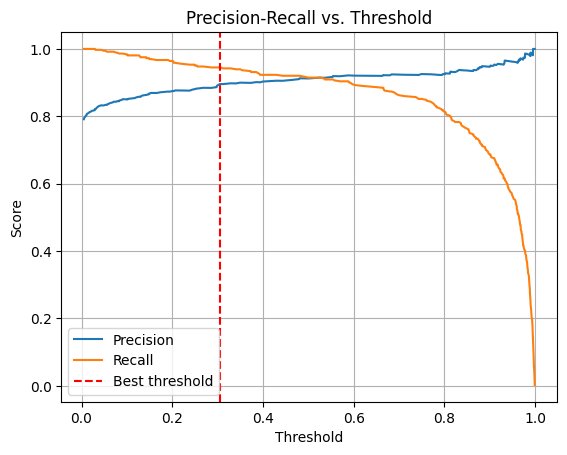

In [43]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=best_thresh, color='r', linestyle='--', label='Best threshold')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs. Threshold")
plt.legend()
plt.grid()
plt.show()


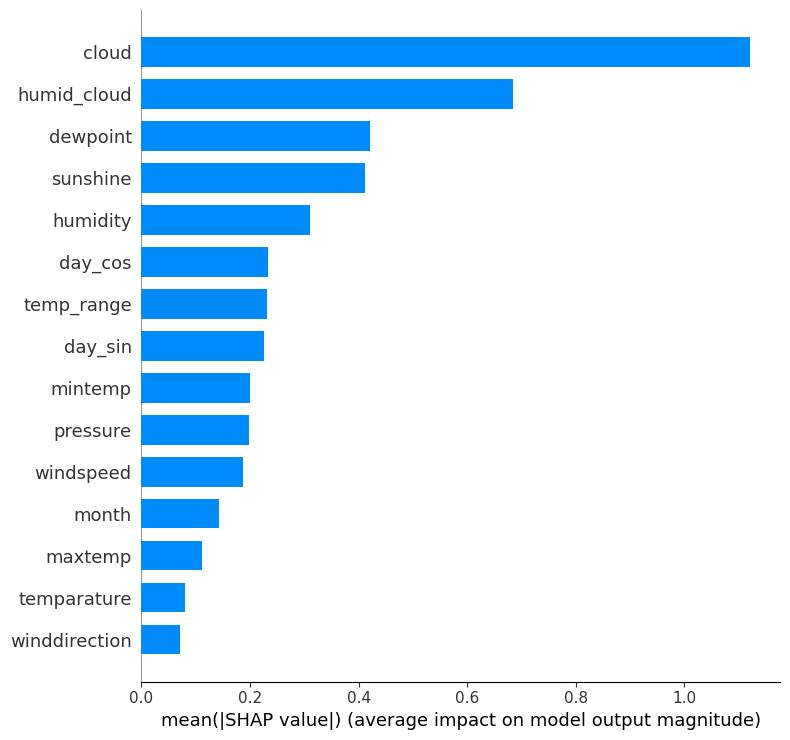

In [44]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")  # bar or dot


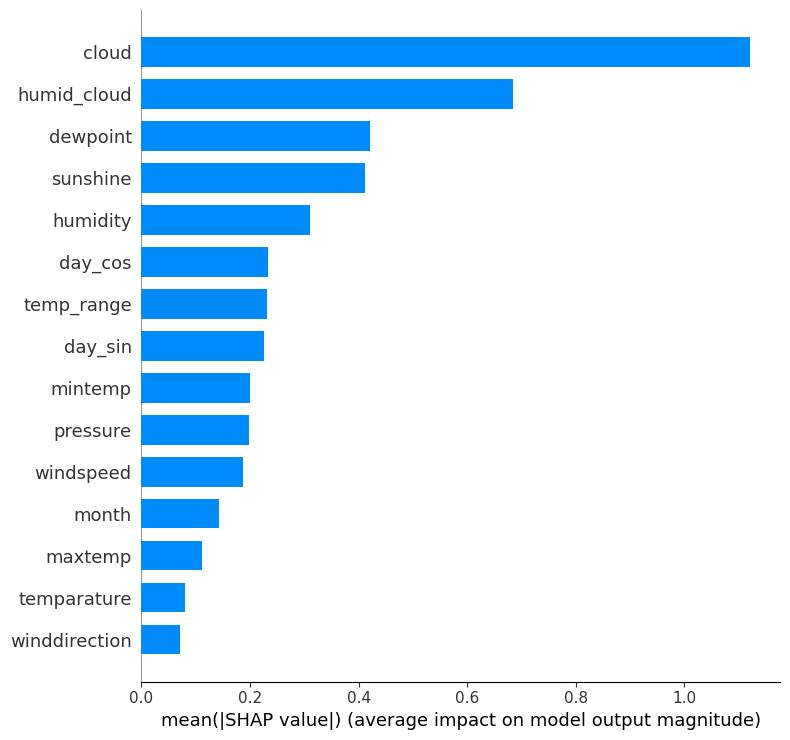

In [45]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")  # bar or dot
